In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.signal import savgol_filter

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 600,
    'svg.fonttype': 'none'
})
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

In [2]:

# =========================
# 1) Load spectral data
# =========================
CSV_PATH = r"C:\Users\LiuDaolong\Desktop\XGB_SHAP\绘图\结果与讨论绘图\Spectra_TS_wavelength.csv"

df = pd.read_csv(CSV_PATH)

# Basic checks
assert "名称" in df.columns, "CSV must contain a column named '名称' with sample IDs like E1, F22..."
# '#'(index) column may exist; we'll ignore it safely
meta_cols = [c for c in ["#", "名称"] if c in df.columns]

# Wavelength columns (nm) are numeric strings
wl_cols = [c for c in df.columns if c not in meta_cols]
# Convert wavelength column names to float
wavelengths_nm = np.array([float(c) for c in wl_cols], dtype=float)

# Sort by wavelength increasing (just in case)
sort_idx = np.argsort(wavelengths_nm)
wavelengths_nm = wavelengths_nm[sort_idx]
wl_cols = [wl_cols[i] for i in sort_idx]

# Spectral matrix: shape (n_samples, n_wavelengths)
X_raw = df[wl_cols].to_numpy(dtype=float)
sample_ids = df["名称"].astype(str).to_numpy()


In [3]:
# =========================
# 2) Parse batch and sampling order, assign stages
#    Early/Middle/Late by thirds within each batch
# =========================
def parse_batch_and_index(s: str):
    """
    Expected sample id format: Letter + number, e.g., E1, F22, K18
    Returns (batch_letter, numeric_index)
    """
    m = re.match(r"^([A-Za-z])\s*0*([0-9]+)$", s.strip())
    if not m:
        raise ValueError(f"Unrecognized sample id format: {s}")
    return m.group(1).upper(), int(m.group(2))

batch = np.array([parse_batch_and_index(s)[0] for s in sample_ids])
idx_in_batch = np.array([parse_batch_and_index(s)[1] for s in sample_ids])

# Create a dataframe to help assign stages
meta = pd.DataFrame({
    "sample_id": sample_ids,
    "batch": batch,
    "idx": idx_in_batch
})

# Assign stage by tertiles within each batch (sorted by idx)
stage = np.empty(len(meta), dtype=object)
for b, g in meta.groupby("batch"):
    g_sorted = g.sort_values("idx")
    n = len(g_sorted)
    # Split into three parts as evenly as possible
    # First third: [0, n1), middle: [n1, n2), late: [n2, n)
    n1 = n // 3
    n2 = 2 * (n // 3)
    # If n not divisible by 3, put remainder into middle/late in a stable way
    # Better: use np.array_split
    parts = np.array_split(g_sorted.index.to_numpy(), 3)
    for part_idx, part in enumerate(parts):
        if part_idx == 0:
            stage[part] = "Early"
        elif part_idx == 1:
            stage[part] = "Middle"
        else:
            stage[part] = "Late"

meta["stage"] = stage


In [4]:
# =========================
# 3) Utility: convert nm to wavenumber cm-1 if you prefer
#    1/cm = 1e7 / nm
# =========================
def nm_to_cm1(wl_nm: np.ndarray) -> np.ndarray:
    return 1e7 / wl_nm

# Choose x-axis mode
USE_WAVENUMBER = False  # set True to use cm^-1
if USE_WAVENUMBER:
    x = nm_to_cm1(wavelengths_nm)
    x_label = "Wavenumber (cm$^{-1}$)"
else:
    x = wavelengths_nm
    x_label = "Wavelength (nm)"

# =========================
# 4) Preprocessing functions for Fig. 7
# =========================
def snv(X: np.ndarray) -> np.ndarray:
    """Standard Normal Variate (row-wise)."""
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-12
    return (X - mu) / sd

def msc(X: np.ndarray, ref: np.ndarray = None) -> np.ndarray:
    """
    Multiplicative Scatter Correction.
    ref: reference spectrum (1D). If None, use mean spectrum.
    """
    if ref is None:
        ref = X.mean(axis=0)
    ref = ref.reshape(1, -1)
    X_corr = np.empty_like(X)
    # Fit each spectrum: x = a + b*ref
    for i in range(X.shape[0]):
        y = X[i, :]
        A = np.vstack([np.ones(ref.size), ref.ravel()]).T
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        a, b = coef[0], coef[1]
        X_corr[i, :] = (y - a) / (b + 1e-12)
    return X_corr

def sg_process(X: np.ndarray, window_length=21, polyorder=2, deriv=0) -> np.ndarray:
    """
    Savitzky-Golay smoothing / derivative (row-wise).
    window_length must be odd and <= number of wavelengths.
    """
    # Ensure valid window length
    wl = X.shape[1]
    if window_length >= wl:
        window_length = wl - 1 if (wl - 1) % 2 == 1 else wl - 2
    if window_length < 5:
        window_length = 5
    if window_length % 2 == 0:
        window_length += 1
    return savgol_filter(X, window_length=window_length, polyorder=polyorder, deriv=deriv, axis=1)


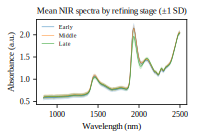

In [5]:
# =========================
# 5) Fig. 5: Mean spectra by stage with ±1 SD shading
# =========================
def plot_fig5_mean_stage(X, meta_df, x, outpath="Fig5_mean_spectra_by_stage.svg"):
    cm_to_inch = 1/2.54  # 厘米转英寸的转换因子
    width_inch = 7 * cm_to_inch
    height_inch = 5 * cm_to_inch
    plt.figure(figsize=(width_inch, height_inch), dpi=600)
    for st in ["Early", "Middle", "Late"]:
        mask = (meta_df["stage"].values == st)
        Xg = X[mask, :]
        mean = Xg.mean(axis=0)
        sd = Xg.std(axis=0)
        plt.plot(x, mean, label=st,linewidth=0.5)
        plt.fill_between(x, mean - sd, mean + sd, alpha=0.2)
    if USE_WAVENUMBER:
        plt.gca().invert_xaxis()  # common in NIR to show cm^-1 decreasing
    plt.xlabel(x_label)
    plt.ylabel("Absorbance (a.u.)")
    plt.title("Mean NIR spectra by refining stage (±1 SD)")
    plt.legend(frameon=False, fontsize=6)
    plt.tight_layout()
    # 保存图像
    plt.savefig(outpath,
                format='svg',
                dpi=600,
                bbox_inches='tight')
    plt.show()

plot_fig5_mean_stage(X_raw, meta, x)


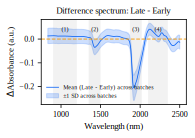

In [6]:
# =========================
# 6) Fig. 6: Difference spectrum (Late - Early) with ±SD of batch-wise differences
#    + highlight key changing regions
# =========================
def plot_fig6_difference_spectrum(
    X,
    meta_df,
    x,
    outpath="Fig6.svg",
    regions=None,
):
    """
    regions: list of tuples (x_start, x_end, label, alpha)
      - x_start/x_end should be in the same unit as x (nm if USE_WAVENUMBER=False; cm-1 otherwise)
      - label: short text shown above the shaded region
      - alpha: transparency
    """
    # ---- compute batch-wise differences ----
    batch_diffs = []
    for b, g in meta_df.groupby("batch"):
        idx = g.index.to_numpy()
        Xb = X[idx, :]
        stages = g["stage"].values
        if ("Early" not in stages) or ("Late" not in stages):
            continue
        mean_early = Xb[stages == "Early", :].mean(axis=0)
        mean_late  = Xb[stages == "Late",  :].mean(axis=0)
        batch_diffs.append(mean_late - mean_early)

    batch_diffs = np.vstack(batch_diffs)
    diff_mean = batch_diffs.mean(axis=0)
    diff_sd = batch_diffs.std(axis=0)

    # ---- default regions (for wavelength in nm) ----
    if regions is None:
        if not USE_WAVENUMBER:
            regions = [
                (900, 1200, "(1)", 0.10),
                (1350, 1500, "(2)", 0.12),
                (1870, 2020, "(3)", 0.12),
                (2100, 2350, "(4)", 0.10),
            ]
        else:
            # If using wavenumber (cm^-1), provide approximate equivalent regions
            # (These are rough conversions: cm^-1 = 1e7 / nm)
            regions = [
                (1e7/1200, 1e7/900,  "2nd overtone (O–H/C–H)", 0.10),
                (1e7/1500, 1e7/1350, "O–H (water)", 0.12),
                (1e7/2000, 1e7/1850, "O–H combination (water)", 0.12),
                (1e7/2350, 1e7/2100, "C–H/O–H/C–O combinations", 0.10),
            ]

    # ---- plot ----
    cm_to_inch = 1 / 2.54
    width_inch = 7 * cm_to_inch
    height_inch = 5 * cm_to_inch

    fig, ax = plt.subplots(figsize=(width_inch, height_inch), dpi=600)

    ax.plot(
        x, diff_mean,
        label="Mean (Late - Early) across batches",
        linewidth=0.8,
        color="#0A63F5"
    )
    ax.fill_between(
        x, diff_mean - diff_sd, diff_mean + diff_sd,
        color="#0A63F5",
        alpha=0.2,
        label="±1 SD across batches"
    )

    # ---- highlight regions ----
    # place labels slightly below top of axis range
    y_top = np.max(diff_mean + diff_sd)
    y_text = y_top - 0.05 * (np.max(diff_mean + diff_sd) - np.min(diff_mean - diff_sd))

    for (x0, x1, lab, a) in regions:
        # for safety, ensure left < right for axvspan (matplotlib is fine either way, but keep consistent)
        left, right = (x0, x1) if x0 < x1 else (x1, x0)
        ax.axvspan(left, right, alpha=a, color="grey", linewidth=0)
        ax.text(
            (left + right) / 2,
            y_text,
            lab,
            ha="center",
            va="top",
            fontsize=6,
            rotation=0
        )

    if USE_WAVENUMBER:
        ax.invert_xaxis()

    ax.axhline(0, linestyle="--", linewidth=1, color="#F59C0A")
    ax.set_xlabel(x_label)
    ax.set_ylabel(r"$\Delta$Absorbance (a.u.)")
    ax.set_title("Difference spectrum: Late - Early")
    ax.legend(frameon=False, fontsize=6, loc='lower left')

    plt.tight_layout()
    plt.savefig(outpath, format="svg", dpi=600, bbox_inches="tight")
    plt.show()


# call
plot_fig6_difference_spectrum(X_raw, meta, x)

In [7]:
import preprocess
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(),  # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1),  # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

In [8]:
def pick_representative_samples(meta_df, batch_letter="G"):
    g = meta_df[meta_df["batch"] == batch_letter].copy()
    if g.empty:
        raise ValueError(f"No samples found for batch {batch_letter}")
    reps = {}
    for st in ["Early", "Middle", "Late"]:
        gs = g[g["stage"] == st].sort_values("idx")
        if gs.empty:
            continue
        # pick median index sample within the stage group
        reps[st] = gs.iloc[len(gs)//2].name  # original row index
    return reps

reps = pick_representative_samples(meta, batch_letter="G")
# Extract representative spectra
X_rep = np.vstack([X_raw[idx, :] for idx in reps.values()])
labels = list(reps.keys())

In [9]:
X_Raw = preprocess_methods["Raw"].fit_transform(X_rep)
X_Detrend = preprocess_methods["Detrend"].fit_transform(X_rep)
X_SNV = preprocess_methods["SNV"].fit_transform(X_rep)
X_MSC = preprocess_methods["MSC"].fit_transform(X_rep)
X_SG_1 = preprocess_methods["SG_1"].fit_transform(X_rep)
X_SG_2 = preprocess_methods["SG_2"].fit_transform(X_rep)


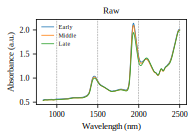

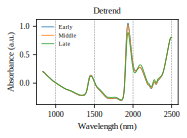

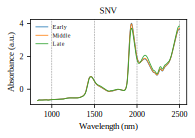

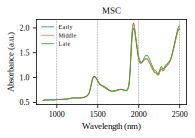

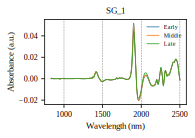

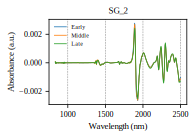

In [10]:
j=0
cm_to_inch = 1/2.54  # 厘米转英寸的转换因子
width_inch = 7 * cm_to_inch
height_inch = 5 * cm_to_inch
for prep_name, prep_obj in preprocess_methods.items():
    j += 1
    X_plot = prep_obj.fit_transform(X_rep)
    plt.figure(figsize=(width_inch, height_inch), dpi=600)
    for i, lab in enumerate(labels):
        plt.plot(x, X_plot[i, :], label=lab,linewidth=0.8)
    if USE_WAVENUMBER:
        plt.gca().invert_xaxis()  # common in NIR to show cm^-1 decreasing
    plt.grid(
    which='both', 
    axis='x', 
    linestyle='--', 
    color='gray', 
    linewidth=0.5
    )
    plt.xlabel(x_label)
    plt.ylabel("Absorbance (a.u.)")
    plt.title(prep_name)
    # plt.legend()
    plt.legend(frameon=False, fontsize=6)
    plt.tight_layout()
    plt.savefig(f'Fig7_{j}.svg', format="svg", dpi=600, bbox_inches="tight")
    plt.show()

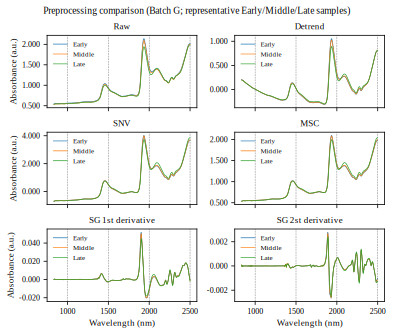

In [13]:
cm_to_inch = 1 / 2.54
width_inch = 14 * cm_to_inch
height_inch = 12 * cm_to_inch
fig, axes = plt.subplots(3, 2, figsize=(width_inch, height_inch), dpi=600, sharex=True)
panels = [
    ("Raw", X_rep),
    ("Detrend", X_Detrend),
    ("SNV", X_SNV),
    ("MSC", X_MSC),
    ("SG 1st derivative", X_SG_1),
    ("SG 2st derivative", X_SG_2)
]
for ax, (title, Xp) in zip(axes.ravel(), panels):
    for i, lab in enumerate(labels):
        ax.plot(x, Xp[i, :], label=lab,linewidth=0.7)
    if USE_WAVENUMBER:
        ax.invert_xaxis()
    ax.set_title(title)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.legend(frameon=False, fontsize=7,loc="upper left")
    # ax.grid(False)
    ax.grid(
    which='both', 
    axis='x', 
    linestyle='--', 
    color='gray', 
    linewidth=0.5
    )

axes[0,0].set_ylabel("Absorbance (a.u.)")
axes[1,0].set_ylabel("Absorbance (a.u.)")
axes[2,0].set_ylabel("Absorbance (a.u.)")
axes[2,0].set_xlabel(x_label)
axes[2,1].set_xlabel(x_label)

# Put legend once
# handles, labs = axes[0,0].get_legend_handles_labels()
# fig.legend(handles, labs, loc="upper center", ncol=3, frameon=False)
# fig.legend(handles, labs, ncol=3, frameon=False)

# fig.suptitle(f"Preprocessing comparison (Batch G; representative Early/Middle/Late samples)", y=0.98)
fig.suptitle(f"Preprocessing comparison (Batch G; representative Early/Middle/Late samples)", y=0.97)

# plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.tight_layout()
plt.savefig('Fig7.svg', format="svg", dpi=600, bbox_inches="tight")
plt.show()